In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('iris.csv')

In [3]:
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [4]:
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.tail(5)

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [6]:
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
print(df.shape)
print(df['species'].unique())

(150, 5)
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [9]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Data Visualization

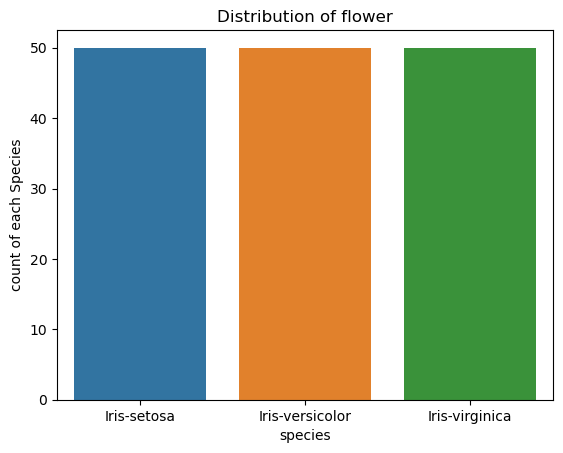

In [10]:
#count Plot
sns.countplot(x='species',hue = 'species',data = df)
plt.title('Distribution of flower')
plt.ylabel('count of each Species')
plt.show()

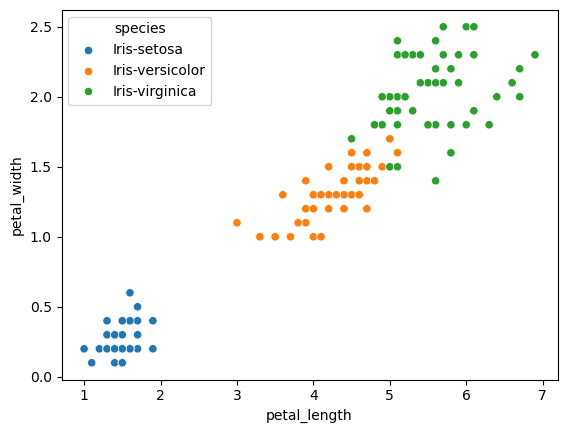

In [11]:
# scatter Plot
sns.scatterplot(x = 'petal_length',y = 'petal_width', hue = 'species', data = df)
plt.show()

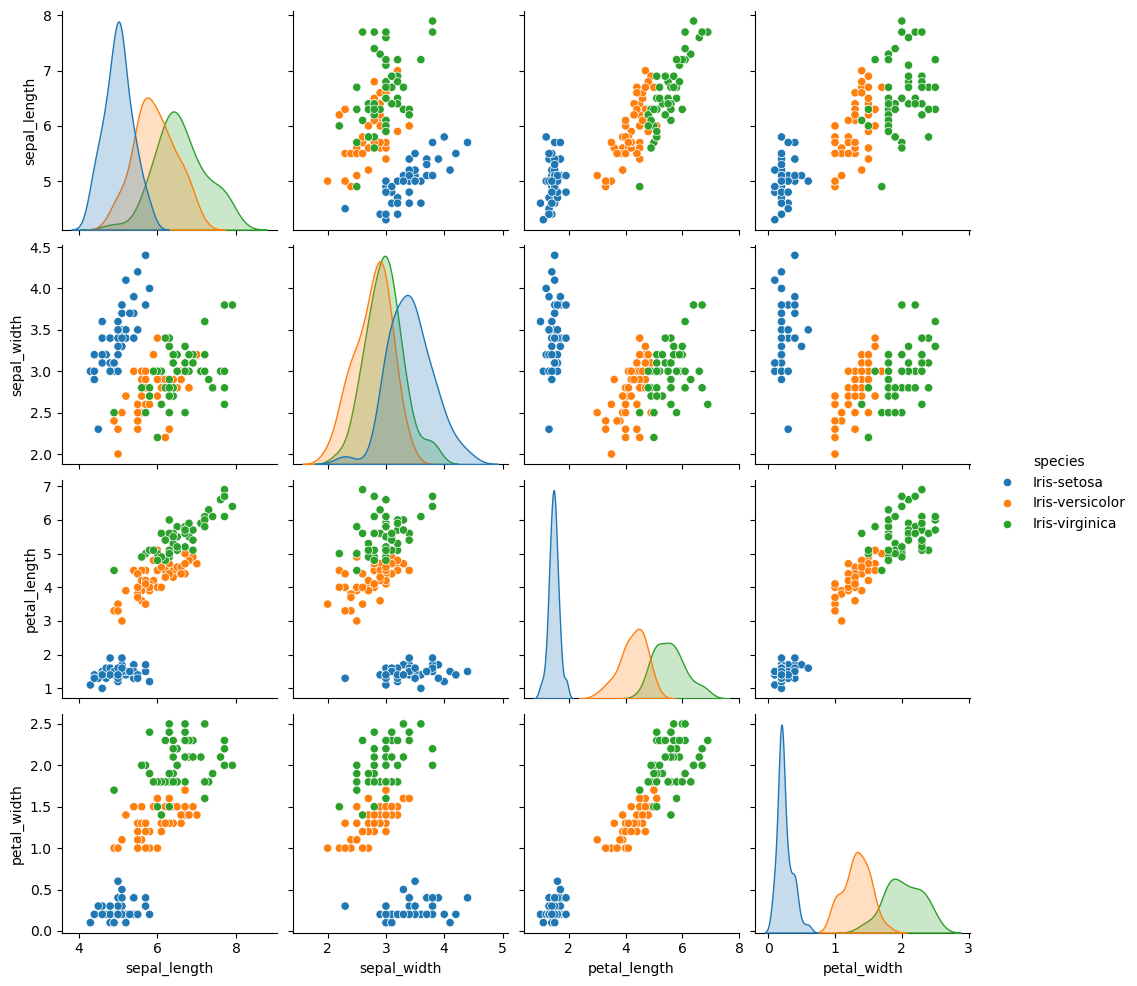

In [12]:
#pair plot
sns.pairplot(df,hue = 'species')
plt.show()

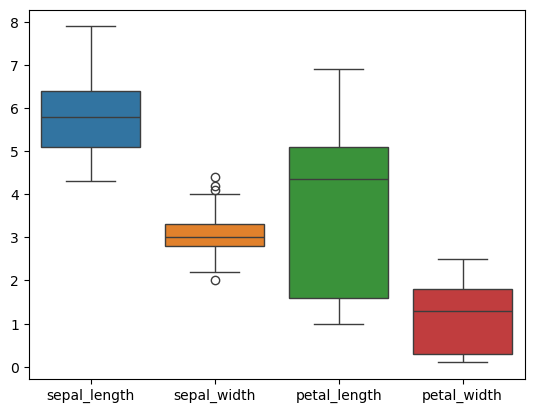

In [13]:
sns.boxplot(data = df)
plt.show()

## Outliers
- Formula:
- IQR = Q3 - Q1
- Lower = Q1 - 1.5 * IQR
- Upper = Q3 + 1.5 * IQR

In [14]:
num_df = df.select_dtypes(include=['float64', 'int64'])
#cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3-Q1
outliers = ((num_df<(Q1 - 1.5*IQR)) | (num_df>(Q3+1.5*IQR)))
print(outliers)

     sepal_length  sepal_width  petal_length  petal_width
0           False        False         False        False
1           False        False         False        False
2           False        False         False        False
3           False        False         False        False
4           False        False         False        False
..            ...          ...           ...          ...
145         False        False         False        False
146         False        False         False        False
147         False        False         False        False
148         False        False         False        False
149         False        False         False        False

[150 rows x 4 columns]


In [15]:
outlier_rows = num_df[(num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))].dropna(how='all')

print(outlier_rows)

    sepal_length  sepal_width  petal_length  petal_width
15           NaN          4.4           NaN          NaN
32           NaN          4.1           NaN          NaN
33           NaN          4.2           NaN          NaN
60           NaN          2.0           NaN          NaN


In [16]:
# show Outlier row from all data
outlier_rows = df[((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))).any(axis=1)]

print(outlier_rows)

    sepal_length  sepal_width  petal_length  petal_width          species
15           5.7          4.4           1.5          0.4      Iris-setosa
32           5.2          4.1           1.5          0.1      Iris-setosa
33           5.5          4.2           1.4          0.2      Iris-setosa
60           5.0          2.0           3.5          1.0  Iris-versicolor


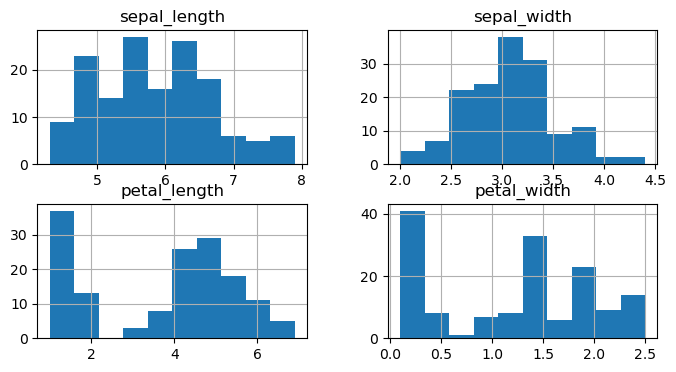

In [17]:
df.hist(figsize = (8,4))
plt.show()

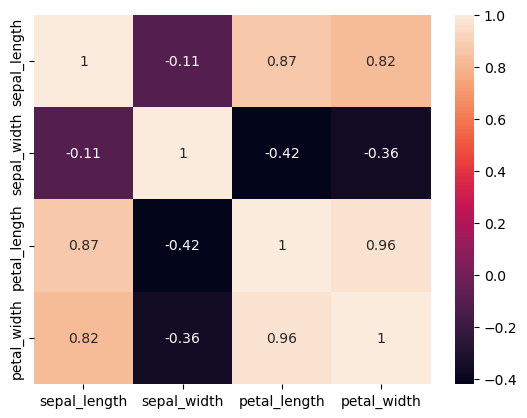

In [18]:
num_df = df.select_dtypes(include=['float64','int64'])
sns.heatmap(num_df.corr(), annot = True)
plt.show()

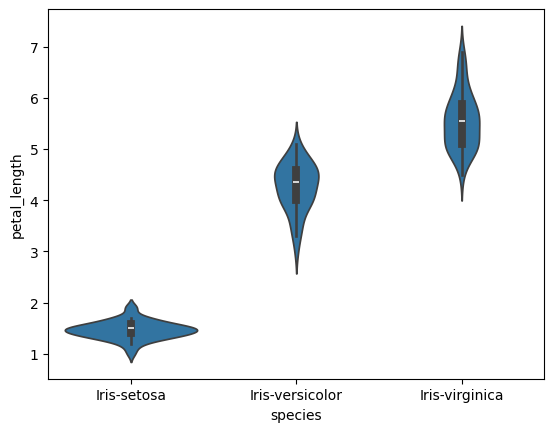

In [19]:
# Voilin plot
sns.violinplot(x = 'species',y = 'petal_length', data =df)
plt.show()

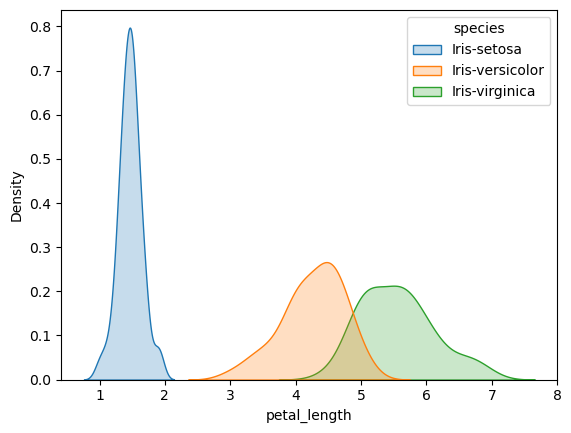

In [20]:
# KDE plot
sns.kdeplot(data=df, x='petal_length', hue='species', fill=True)
plt.show()

In [21]:
#SPLITTING THE DATA INTO INPUT AND OUTPUT we have two way
#x = iris[['sepal_length','sepal_width','petal_length','petal_width']]
#y = iris['species']
     #or
x = df.drop('species',axis = 1)
y = df['species']

In [22]:
print(x.shape)
print(y.shape)

(150, 4)
(150,)


In [23]:
#SPLITTING INTO TRAIN AND TEST
from sklearn.model_selection import train_test_split

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2,random_state = 42)

In [25]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(120, 4)
(120,)
(30, 4)
(30,)


In [26]:
x_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(x_train,y_train)
knn_pred = knn.predict(x_test)

In [29]:
from sklearn.metrics import accuracy_score
print('Accuracy',accuracy_score(y_test,knn_pred)*100)

Accuracy 100.0


In [31]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,knn_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [32]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)

In [34]:
print("Accuracy = ", accuracy_score(y_test,lr_pred)*100)
print("Matrix \n", confusion_matrix(y_test,lr_pred))

Accuracy =  100.0
Matrix 
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [35]:
from sklearn.ensemble import RandomForestClassifier
fr = RandomForestClassifier()
fr.fit(x_train,y_train)
fr_pred = fr.predict(x_test)

In [36]:
print('Accuracy',accuracy_score(y_test,fr_pred)*100)
print(confusion_matrix(y_test,fr_pred))

Accuracy 100.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [37]:
print("KNN",accuracy_score(y_test,knn_pred))
print("Logistic",accuracy_score(y_test,lr_pred))
print("Forest",accuracy_score(y_test,fr_pred))

KNN 1.0
Logistic 1.0
Forest 1.0


In [38]:
importance = fr.feature_importances_
feature_names = x.columns

pd.Series(importance, index=feature_names).sort_values(ascending=False)

petal_length    0.477286
petal_width     0.365151
sepal_length    0.123416
sepal_width     0.034146
dtype: float64

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, fr_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



<Axes: >

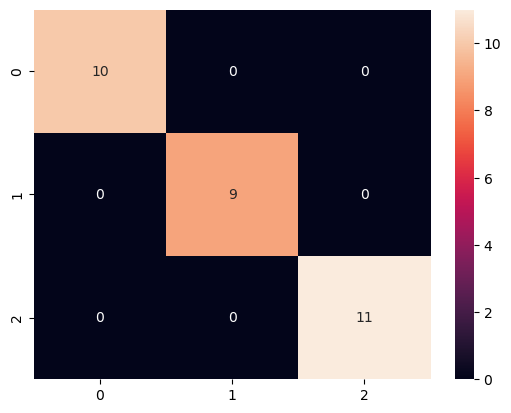

In [43]:
cm = confusion_matrix(y_test,fr_pred)
sns.heatmap(cm,annot = True,fmt = 'd')

In [47]:
import joblib

joblib.dump(fr, 'iris_model.pkl')

['iris_model.pkl']

In [49]:
new_data = [[5.1, 3.5, 1.4, 0.2]]

prediction = fr.predict(new_data)
print(prediction)

['Iris-setosa']


C:\Users\rizwa\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [50]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
